# FocalNet-Tiny SRF Fine-Tuning for Aerial Scene Classification

This notebook fine-tunes an ImageNet-pretrained **FocalNet-Tiny SRF** model for the CSC3109 aerial-image classification task. The four target classes are **bridge**, **freeway**, **overpass**, and **railway**.

FocalNet is a hierarchical vision backbone designed as an alternative to standard self-attention. Instead of computing pairwise attention between all image tokens, FocalNet uses **focal modulation**: it aggregates context over multiple spatial scales and uses that context to modulate local visual features. This is useful for aerial scene classification because the class label often depends on both local texture and wider spatial layout.

Everything below walks through the full pipeline: verify the dataset, load the FocalNet-Tiny SRF backbone from `timm`, fine-tune all 27.7M parameters, select the best checkpoint via tune-set macro-F1, and evaluate once on the held-out `data/raw/val` split.

## What this notebook covers

This notebook walks through one complete FocalNet fine-tuning run on the CSC3109 aerial-image dataset:

1. Environment check — Python, PyTorch, CUDA, and `timm` versions.
2. Dataset inspection — verify the ImageFolder layout and check for exact and near-duplicate images across `data/raw/train` and `data/raw/val`.
3. Architecture overview — a quick look at FocalNet-Tiny SRF and why focal modulation is a reasonable fit for aerial scenes.
4. Model construction — load the ImageNet-pretrained backbone through `timm` with a fresh 4-class classifier head.
5. Internal train/tune split — 80/20 from `data/raw/train` for checkpoint selection.
6. Full fine-tuning — all 27.7M parameters trained with AdamW + cosine LR.
7. Tune evaluation — macro-F1 checkpoint selection, a tune-loss tie-break, early stopping, and learning curves.
8. Held-out evaluation — one final pass on `data/raw/val` after training.
9. Results summary — the final metrics and confusion matrix shown directly in the notebook.

The held-out validation set (`data/raw/val`) is never used for training, hyperparameter tuning, or checkpoint selection. Cells that inspect it do so read-only. One important limitation still remains: an image-level split can miss near-duplicate or adjacent aerial tiles, so a perfect tune score should be treated carefully rather than taken as automatic proof of generalisation.

## 1. Project setup

In [1]:
from pathlib import Path
import sys

# Resolve the project root and add it to sys.path so we can import shared utilities from src/.
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f'Project root: {PROJECT_ROOT.name}')

Project root: CSC3109_Project


In [2]:
import hashlib
import json
import math
import random
from datetime import datetime, timezone

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from torch import nn
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

import timm
from torchvision import datasets

from src.config import CLASS_NAMES, MODEL_DIR, REPORTS_DIR, NUM_CLASSES
from src.data import build_eval_transform, build_internal_split_dataloaders
from src.evaluation import (
    classification_metrics,
    save_confusion_matrix_plot,
    write_epoch_history_csv,
    write_metrics_json,
)
from src.models import (
    FOCALNET_TINY_SRF,
    build_timm_classifier,
    get_timm_preprocess_settings,
    resolve_timm_model_name,
    trainable_parameters,
)

## 2. Environment and dependencies

A quick check records the active library versions and confirms CUDA availability.

**Held-out validation integrity note:** the next dataset sanity cells may read `data/raw/val` only for read-only checks. The held-out validation images are not used for gradient updates, hyperparameter tuning, or checkpoint selection. Final model evaluation is performed only in the final **RUN ONCE** section.


In [3]:
print(f'torch: {torch.__version__}')
print(f'timm: {timm.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'CUDA device: {torch.cuda.get_device_name(0)}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

torch: 2.12.0+cu130
timm: 1.0.27
CUDA available: True
CUDA device: NVIDIA GeForce RTX 4080 SUPER


device(type='cuda')

## 3. Dataset setup and leakage checks

The project dataset is stored in an ImageFolder-style layout. Each class has its own directory under `data/raw/train` and `data/raw/val`.

Before training, we verify a few things:

- both `data/raw/train` and `data/raw/val` exist;
- class folders match `bridge`, `freeway`, `overpass`, `railway`;
- no byte-identical images leak across the two official splits;
- no obvious near-duplicate images (resized, recompressed, or adjacent crops) span the splits.

The exact-hash check is a fast first pass. The near-duplicate check that follows is the more important one for aerial data, because visually similar tiles can leak across a random split without ever being byte-identical.

In [4]:
TRAIN_DIR = PROJECT_ROOT / 'data' / 'raw' / 'train'
HELDOUT_VAL_DIR = PROJECT_ROOT / 'data' / 'raw' / 'val'

if not TRAIN_DIR.exists():
    raise FileNotFoundError(f'Missing training directory: {TRAIN_DIR}')
if not HELDOUT_VAL_DIR.exists():
    raise FileNotFoundError(f'Missing held-out validation directory: {HELDOUT_VAL_DIR}')

print(f'TRAIN_DIR = {TRAIN_DIR.resolve().relative_to(PROJECT_ROOT.resolve())}')
print(f'HELDOUT_VAL_DIR = {HELDOUT_VAL_DIR.resolve().relative_to(PROJECT_ROOT.resolve())}')

TRAIN_DIR = data/raw/train
HELDOUT_VAL_DIR = data/raw/val


In [5]:
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def image_paths_by_class(root: Path) -> dict[str, list[Path]]:
    paths = {}
    for class_dir in sorted(path for path in root.iterdir() if path.is_dir()):
        paths[class_dir.name] = sorted(
            path for path in class_dir.rglob('*') if path.suffix.lower() in IMAGE_EXTENSIONS
        )
    return paths

train_paths = image_paths_by_class(TRAIN_DIR)
heldout_paths = image_paths_by_class(HELDOUT_VAL_DIR)
counts = pd.DataFrame({
    'class_name': sorted(set(train_paths) | set(heldout_paths)),
}).assign(
    train_count=lambda df: df['class_name'].map(lambda name: len(train_paths.get(name, []))),
    heldout_val_count=lambda df: df['class_name'].map(lambda name: len(heldout_paths.get(name, []))),
)
display(counts)

if set(counts['class_name']) != set(CLASS_NAMES):
    raise ValueError(f'Unexpected class folders found: {counts}')

,class_name,train_count,heldout_val_count
0,bridge,700,100
1,freeway,700,100
2,overpass,700,100
3,railway,700,100


### Visual sample check

A small random sample from the training set helps confirm that the class folders contain the expected aerial-scene imagery. Quick sanity check before training

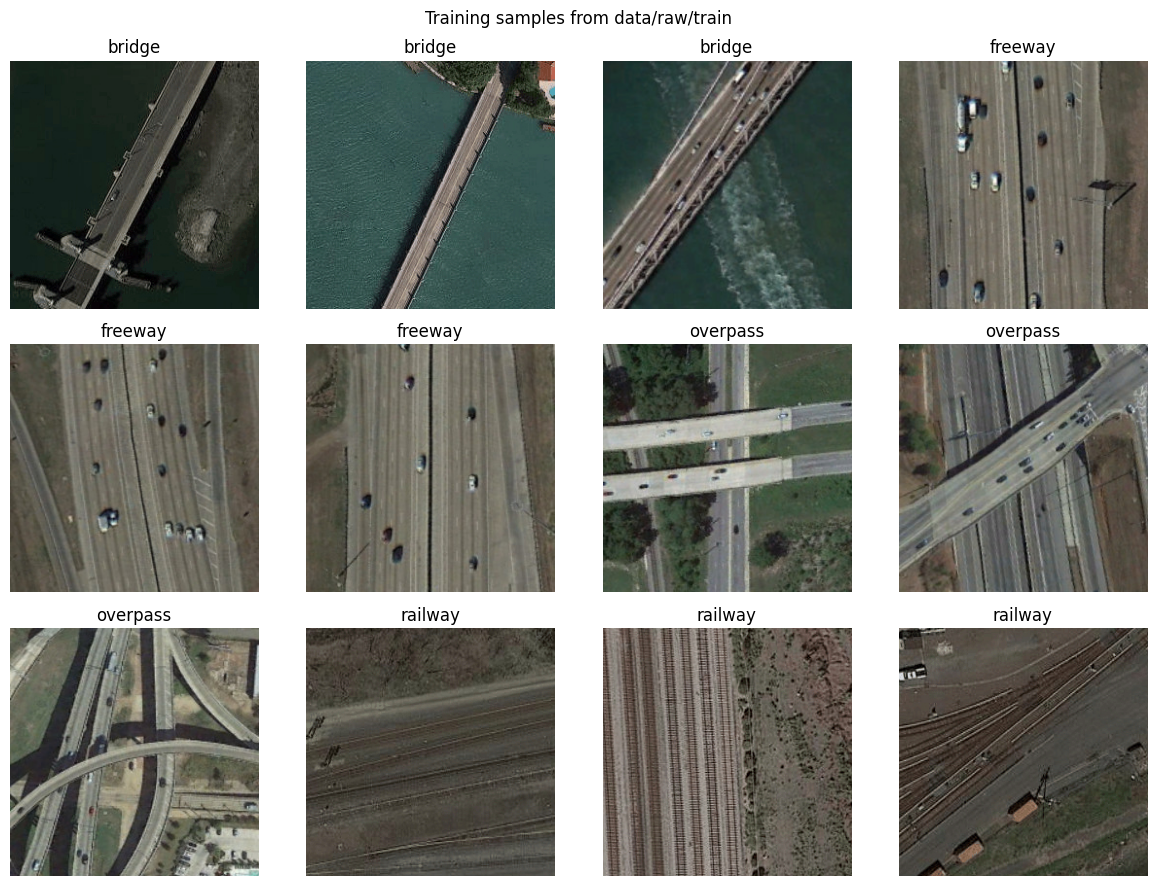

In [6]:
rng = random.Random(42)
sample_paths = []
for class_name in CLASS_NAMES:
    candidates = train_paths.get(class_name, [])
    sample_paths.extend(rng.sample(candidates, k=min(3, len(candidates))))

cols = 4
rows = max(1, math.ceil(len(sample_paths) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(12, 3 * rows))
axes = np.atleast_1d(axes).ravel()
for ax, path in zip(axes, sample_paths):
    ax.imshow(Image.open(path).convert('RGB'))
    ax.set_title(path.parent.name)
    ax.axis('off')
for ax in axes[len(sample_paths):]:
    ax.axis('off')
fig.suptitle('Training samples from data/raw/train')
fig.tight_layout()

### Exact-hash duplicate check

The next cell hashes each image file with SHA-256. That catches exact duplicate files and any exact train/val overlap, but it does **not** catch visually similar tiles from the same source scene. So a clean result here reduces one kind of leakage risk without ruling out all of them.

In [7]:
def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open('rb') as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()


def hash_groups(paths_by_class: dict[str, list[Path]]) -> dict[str, list[Path]]:
    groups: dict[str, list[Path]] = {}
    for paths in paths_by_class.values():
        for path in paths:
            groups.setdefault(sha256_file(path), []).append(path)
    return groups


train_hash_groups = hash_groups(train_paths)
heldout_hash_groups = hash_groups(heldout_paths)
train_internal_duplicate_hashes = sorted(hash_value for hash_value, paths in train_hash_groups.items() if len(paths) > 1)
heldout_internal_duplicate_hashes = sorted(hash_value for hash_value, paths in heldout_hash_groups.items() if len(paths) > 1)
cross_split_duplicate_hashes = sorted(set(train_hash_groups) & set(heldout_hash_groups))

duplicate_summary = pd.DataFrame([
    {'check': 'duplicate hashes inside train', 'count': len(train_internal_duplicate_hashes)},
    {'check': 'duplicate hashes inside held-out val', 'count': len(heldout_internal_duplicate_hashes)},
    {'check': 'duplicate hashes shared across train and held-out val', 'count': len(cross_split_duplicate_hashes)},
])
display(duplicate_summary)

if train_internal_duplicate_hashes:
    display(pd.DataFrame([
        {
            'split': 'train',
            'hash': hash_value,
            'copies': len(train_hash_groups[hash_value]),
            'example_path': str(train_hash_groups[hash_value][0]),
        }
        for hash_value in train_internal_duplicate_hashes[:10]
    ]))

if heldout_internal_duplicate_hashes:
    display(pd.DataFrame([
        {
            'split': 'held-out val',
            'hash': hash_value,
            'copies': len(heldout_hash_groups[hash_value]),
            'example_path': str(heldout_hash_groups[hash_value][0]),
        }
        for hash_value in heldout_internal_duplicate_hashes[:10]
    ]))

if cross_split_duplicate_hashes:
    display(pd.DataFrame([
        {
            'hash': hash_value,
            'train_path': str(train_hash_groups[hash_value][0]),
            'heldout_val_path': str(heldout_hash_groups[hash_value][0]),
        }
        for hash_value in cross_split_duplicate_hashes[:20]
    ]))
    raise ValueError('Found duplicate image bytes across train and held-out validation splits.')

,check,count
0,duplicate hashes inside train,0
1,duplicate hashes inside held-out val,0
2,duplicate hashes shared across train and held-...,0


### Near-duplicate check (perceptual hash)

Exact hashing only catches identical files. For aerial imagery the more realistic leakage risk is **near-duplicates**: resized or recompressed copies, and especially adjacent crops of the same scene. Those have different bytes but look almost identical.

The cell below computes a 256-bit **difference hash (dHash)** for every image and compares them by Hamming distance. The threshold was calibrated on this dataset so that flagged pairs stay within the same class — a coarser hash tends to collapse low-contrast aerial tiles together and produce cross-class false positives. It reports three things:

- near-duplicate pairs **inside train** — these can land on opposite sides of the random train/tune split and make the tune score look easier than it is;
- near-duplicate pairs **inside held-out val**;
- near-duplicate pairs **across train and held-out val** — the most direct leakage risk for the final result.

This is informational. It prints counts and example pairs rather than stopping the run, so the limitation is visible alongside the numbers instead of hidden.

In [8]:
NEAR_DUP_HASH_SIZE = 16
NEAR_DUP_HAMMING_THRESHOLD = 16  # out of 256 bits; calibrated so flagged pairs stay within-class

def dhash_bits(path: Path, hash_size: int = NEAR_DUP_HASH_SIZE) -> np.ndarray:
    with Image.open(path) as image:
        resized = image.convert('L').resize((hash_size + 1, hash_size), Image.BILINEAR)
    pixels = np.asarray(resized, dtype=np.int16)
    return np.packbits((pixels[:, 1:] > pixels[:, :-1]).flatten())

def hamming_distances(query_bits: np.ndarray, candidate_bits: np.ndarray) -> np.ndarray:
    return np.unpackbits(np.bitwise_xor(query_bits, candidate_bits), axis=1).sum(axis=1)

def within_near_dup_pairs(hashes: np.ndarray, threshold: int) -> list[tuple[int, int, int]]:
    pairs = []
    for i in range(len(hashes) - 1):
        distances = hamming_distances(hashes[i], hashes[i + 1:])
        for offset in np.nonzero(distances <= threshold)[0]:
            pairs.append((i, i + 1 + int(offset), int(distances[offset])))
    return pairs

def cross_near_dup_pairs(left: np.ndarray, right: np.ndarray, threshold: int) -> list[tuple[int, int, int]]:
    pairs = []
    for i in range(len(left)):
        distances = hamming_distances(left[i], right)
        for j in np.nonzero(distances <= threshold)[0]:
            pairs.append((i, int(j), int(distances[j])))
    return pairs

train_flat = [(class_name, path) for class_name, paths in train_paths.items() for path in paths]
heldout_flat = [(class_name, path) for class_name, paths in heldout_paths.items() for path in paths]
train_dhashes = np.array([dhash_bits(path) for _, path in train_flat])
heldout_dhashes = np.array([dhash_bits(path) for _, path in heldout_flat])

train_near_pairs = within_near_dup_pairs(train_dhashes, NEAR_DUP_HAMMING_THRESHOLD)
heldout_near_pairs = within_near_dup_pairs(heldout_dhashes, NEAR_DUP_HAMMING_THRESHOLD)
cross_near_pairs = cross_near_dup_pairs(train_dhashes, heldout_dhashes, NEAR_DUP_HAMMING_THRESHOLD)

near_dup_summary = pd.DataFrame([
    {'check': 'near-duplicate pairs inside train', 'pairs': len(train_near_pairs), 'images_involved': len({i for pair in train_near_pairs for i in pair[:2]})},
    {'check': 'near-duplicate pairs inside held-out val', 'pairs': len(heldout_near_pairs), 'images_involved': len({i for pair in heldout_near_pairs for i in pair[:2]})},
    {'check': 'near-duplicate pairs across train and held-out val', 'pairs': len(cross_near_pairs), 'images_involved': len({j for _, j, _ in cross_near_pairs})},
])
print(f'dHash: {NEAR_DUP_HASH_SIZE}x{NEAR_DUP_HASH_SIZE} ({NEAR_DUP_HASH_SIZE * NEAR_DUP_HASH_SIZE} bits), Hamming threshold: {NEAR_DUP_HAMMING_THRESHOLD}')
display(near_dup_summary)

def show_example_pairs(pairs, left_flat, right_flat, title, limit=10):
    if not pairs:
        return
    rows = []
    for left_index, right_index, distance in sorted(pairs, key=lambda item: item[2])[:limit]:
        left_class, left_path = left_flat[left_index]
        right_class, right_path = right_flat[right_index]
        rows.append({
            'hamming': distance,
            'left_class': left_class,
            'left_file': left_path.name,
            'right_class': right_class,
            'right_file': right_path.name,
        })
    print(title)
    display(pd.DataFrame(rows))

show_example_pairs(train_near_pairs, train_flat, train_flat, 'Closest near-duplicate pairs inside train:')
show_example_pairs(cross_near_pairs, train_flat, heldout_flat, 'Closest near-duplicate pairs across train and held-out val:')

if cross_near_pairs:
    print(f'WARNING: {len(cross_near_pairs)} near-duplicate pair(s) span train and held-out val; the held-out score may be optimistic.')
else:
    print('No near-duplicate pairs detected across train and held-out val at this threshold.')
if train_near_pairs:
    print(f'Note: {len(train_near_pairs)} near-duplicate pair(s) inside train can land on opposite sides of the random train/tune split.')

dHash: 16x16 (256 bits), Hamming threshold: 16


,check,pairs,images_involved
0,near-duplicate pairs inside train,5,9
1,near-duplicate pairs inside held-out val,0,0
2,near-duplicate pairs across train and held-out...,0,0


Closest near-duplicate pairs inside train:


,hamming,left_class,left_file,right_class,right_file
0,5,freeway,freeway379.jpg,freeway,freeway380.jpg
1,13,freeway,freeway375.jpg,freeway,freeway376.jpg
2,14,freeway,freeway351.jpg,freeway,freeway352.jpg
3,15,freeway,freeway432.jpg,freeway,freeway433.jpg
4,16,freeway,freeway352.jpg,freeway,freeway353.jpg


No near-duplicate pairs detected across train and held-out val at this threshold.
Note: 5 near-duplicate pair(s) inside train can land on opposite sides of the random train/tune split.


## 4. Experiment configuration

The run loads `focalnet-tiny-srf` with ImageNet pretrained weights. The learning rate is set low (`3e-5`) because we're fine-tuning the entire backbone, not just the classifier head.

Key design choices:

- **Image size:** 224 × 224, matching the project default and the model's pretrained configuration.
- **Loss:** cross-entropy with label smoothing to reduce over-confident predictions.
- **Optimizer:** AdamW with weight decay for regularised full fine-tuning.
- **Selection metric:** macro-F1 on the internal tune split, with tune loss as a tie-break when macro-F1 is effectively the same.
- **Early stopping:** stops training if the tune score stops improving for several epochs.

In [9]:
MODEL_NAME = 'focalnet-tiny-srf'
SEED = 42
IMAGE_SIZE = 224
EPOCHS = 20
BATCH_SIZE = 16
NUM_WORKERS = 0
LR = 3e-5
WEIGHT_DECAY = 0.05
LABEL_SMOOTHING = 0.1
TUNE_RATIO = 0.2
PATIENCE = 5
MIN_DELTA = 1e-4

RUN_LABEL = 'final'
RUN_DIR = MODEL_DIR / 'focalnet_tiny_srf_notebook' / RUN_LABEL
OUTPUT_DIR = RUN_DIR
REPORT_DIR = REPORTS_DIR / 'focalnet_tiny_srf_notebook_eval'
MAX_TRAIN_BATCHES = None
MAX_TUNE_BATCHES = None
EPOCHS_TO_RUN = EPOCHS
PRETRAINED = True

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Run label: {RUN_LABEL}')
print(f'Pretrained: {PRETRAINED}, epochs_to_run={EPOCHS_TO_RUN}')
print(f'Output dir: {OUTPUT_DIR.resolve().relative_to(PROJECT_ROOT.resolve())}')
print(f'Report dir: {REPORT_DIR.resolve().relative_to(PROJECT_ROOT.resolve())}')

Run label: final
Pretrained: True, epochs_to_run=20
Output dir: model/focalnet_tiny_srf_notebook/final
Report dir: reports/focalnet_tiny_srf_notebook_eval


### Hyperparameter summary

A quick summary of the hyperparameters for this run:

In [10]:
hyperparameter_table = pd.DataFrame([
    {'setting': 'model', 'value': MODEL_NAME, 'reason': 'FocalNet-Tiny SRF pretrained backbone from timm'},
    {'setting': 'image_size', 'value': IMAGE_SIZE, 'reason': 'standard 224×224 ImageNet-style input'},
    {'setting': 'epochs', 'value': EPOCHS, 'reason': 'upper bound; early stopping may stop sooner'},
    {'setting': 'batch_size', 'value': BATCH_SIZE, 'reason': 'fits the available GPU/CPU memory budget'},
    {'setting': 'learning_rate', 'value': LR, 'reason': 'conservative LR for pretrained full fine-tuning'},
    {'setting': 'weight_decay', 'value': WEIGHT_DECAY, 'reason': 'regularises the fine-tuned weights'},
    {'setting': 'label_smoothing', 'value': LABEL_SMOOTHING, 'reason': 'discourages over-confident predictions'},
    {'setting': 'tune_ratio', 'value': TUNE_RATIO, 'reason': 'internal validation split from training data'},
    {'setting': 'patience', 'value': PATIENCE, 'reason': 'early stopping on tune macro-F1'},
])
display(hyperparameter_table)


,setting,value,reason
0,model,focalnet-tiny-srf,FocalNet-Tiny SRF pretrained backbone from timm
1,image_size,224,standard 224×224 ImageNet-style input
2,epochs,20,upper bound; early stopping may stop sooner
3,batch_size,16,fits the available GPU/CPU memory budget
4,learning_rate,0.00003,conservative LR for pretrained full fine-tuning
5,weight_decay,0.05,regularises the fine-tuned weights
6,label_smoothing,0.1,discourages over-confident predictions
7,tune_ratio,0.2,internal validation split from training data
8,patience,5,early stopping on tune macro-F1


In [11]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

## 5. FocalNet architecture and model construction

FocalNet is a hierarchical image model. At a high level, it follows the same coarse pattern as many modern vision backbones: split the image into patches, process the representation through multiple feature stages, aggregate the final representation, and apply a classifier head.

The key architectural idea is **focal modulation**. Instead of using explicit self-attention over every pair of tokens, FocalNet gathers contextual information at multiple spatial ranges and uses that context to modulate local features. For aerial imagery, this is a reasonable fit because classes such as bridges and overpasses can depend on both fine details and larger scene structure.

We load the architecture and pretrained weights from `timm` via the project helper `build_timm_classifier`, swapping the original ImageNet head for a four-class linear layer.

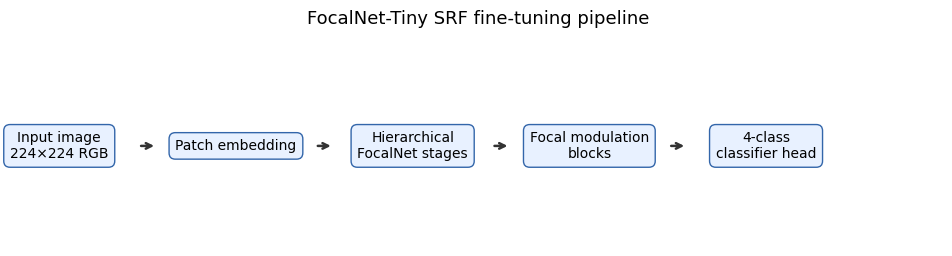

In [12]:
# Simple schematic of the FocalNet fine-tuning pipeline used in this notebook.
fig, ax = plt.subplots(figsize=(12, 2.6))
ax.axis('off')

boxes = [
    ('Input image\n224×224 RGB', 0.05),
    ('Patch embedding', 0.24),
    ('Hierarchical\nFocalNet stages', 0.43),
    ('Focal modulation\nblocks', 0.62),
    ('4-class\nclassifier head', 0.81),
]

for label, x in boxes:
    ax.text(
        x, 0.5, label,
        ha='center', va='center', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.45', facecolor='#e8f1ff', edgecolor='#3366aa'),
        transform=ax.transAxes,
    )

for (_, x1), (_, x2) in zip(boxes, boxes[1:]):
    ax.annotate(
        '', xy=(x2 - 0.085, 0.5), xytext=(x1 + 0.085, 0.5),
        xycoords=ax.transAxes, textcoords=ax.transAxes,
        arrowprops=dict(arrowstyle='->', lw=1.8, color='#333333'),
    )

ax.set_title('FocalNet-Tiny SRF fine-tuning pipeline', fontsize=13, pad=16)
plt.show()


In [13]:
resolved_model_name = resolve_timm_model_name(MODEL_NAME)
available = resolved_model_name in timm.list_models(resolved_model_name)
preprocess = get_timm_preprocess_settings(MODEL_NAME)
print(f'Alias: {MODEL_NAME}')
print(f'timm model: {resolved_model_name}')
print(f'Available in timm registry: {available}')
print(f'Preprocess: {preprocess}')
if not available:
    raise ValueError(f'{resolved_model_name} is not available in this timm install.')

model = build_timm_classifier(
    num_classes=NUM_CLASSES,
    model_name=MODEL_NAME,
    pretrained=PRETRAINED,
    image_size=IMAGE_SIZE,
).to(device)

total_params = sum(parameter.numel() for parameter in model.parameters())
trainable_params = sum(parameter.numel() for parameter in trainable_parameters(model))
print(f'Total parameters: {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

Alias: focalnet-tiny-srf
timm model: focalnet_tiny_srf
Available in timm registry: True
Preprocess: {'input_size': (3, 224, 224), 'mean': (0.485, 0.456, 0.406), 'std': (0.229, 0.224, 0.225), 'interpolation': 'bicubic'}


Total parameters: 27,661,192
Trainable parameters: 27,661,192


### Fine-tuning mode

This run performs **full fine-tuning**, not PEFT and not linear probing. The model is created with the default `classifier_only=False`, so the pretrained FocalNet backbone and the newly adapted classifier head remain trainable.

The optimizer receives `trainable_parameters(model)`. Since nothing is frozen, this covers all 27.7M parameters.

In [14]:
parameter_summary = pd.DataFrame([
    {'parameter_group': 'total parameters', 'count': total_params},
    {'parameter_group': 'trainable parameters', 'count': trainable_params},
])
parameter_summary['count_millions'] = parameter_summary['count'] / 1_000_000
parameter_summary['share_of_model'] = parameter_summary['count'] / total_params

display(parameter_summary)

if trainable_params == total_params:
    print('All model parameters are trainable: this is full fine-tuning.')
else:
    print('Only a subset of parameters is trainable: check freezing/classifier_only settings.')


,parameter_group,count,count_millions,share_of_model
0,total parameters,27661192,27.661192,1.0
1,trainable parameters,27661192,27.661192,1.0


All model parameters are trainable: this is full fine-tuning.


## 6. Internal train/tune loaders from `data/raw/train`

The official validation folder remains untouched for model selection. Instead, this cell builds an internal split from `data/raw/train`:

- the larger portion is used for gradient updates;
- the tune portion is used for checkpoint selection and early stopping;
- both splits use preprocessing settings resolved from the FocalNet pretrained configuration.

This is a deterministic **stratified image-level split**. That keeps class balance under control, but it is still not a scene-aware split, so nearby or highly similar aerial crops could still make the tune set easier than a truly independent evaluation set.

In [15]:
mean = tuple(float(value) for value in preprocess['mean'])
std = tuple(float(value) for value in preprocess['std'])
interpolation = str(preprocess['interpolation'])

train_loader, tune_loader, class_to_idx = build_internal_split_dataloaders(
    train_dir=TRAIN_DIR,
    tune_ratio=TUNE_RATIO,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=device.type == 'cuda',
    seed=SEED,
    mean=mean,
    std=std,
    interpolation=interpolation,
)
class_names = [name for name, _ in sorted(class_to_idx.items(), key=lambda item: item[1])]
if class_names != list(CLASS_NAMES):
    raise ValueError(f'Unexpected class order: {class_names}')

display(pd.DataFrame({'class_name': class_names, 'class_index': list(range(len(class_names)))}))
print(f'Train images: {len(train_loader.dataset)}')
print(f'Tune images: {len(tune_loader.dataset)}')

train_split_paths = [Path(train_loader.dataset.dataset.samples[index][0]) for index in train_loader.dataset.indices]
tune_split_paths = [Path(tune_loader.dataset.dataset.samples[index][0]) for index in tune_loader.dataset.indices]
train_split_hashes: dict[str, list[Path]] = {}
tune_split_hashes: dict[str, list[Path]] = {}
for path in train_split_paths:
    train_split_hashes.setdefault(sha256_file(path), []).append(path)
for path in tune_split_paths:
    tune_split_hashes.setdefault(sha256_file(path), []).append(path)
internal_overlap_hashes = sorted(set(train_split_hashes) & set(tune_split_hashes))
print(f'Exact duplicate hashes shared by internal train/tune split: {len(internal_overlap_hashes)}')
if internal_overlap_hashes:
    display(pd.DataFrame([
        {
            'hash': hash_value,
            'train_path': str(train_split_hashes[hash_value][0]),
            'tune_path': str(tune_split_hashes[hash_value][0]),
        }
        for hash_value in internal_overlap_hashes[:20]
    ]))
    raise ValueError('Found exact duplicate image bytes shared by the internal train/tune split.')

sample_images, sample_labels = next(iter(tune_loader))
with torch.no_grad():
    sample_logits = model(sample_images[: min(4, sample_images.size(0))].to(device))
print(f'Sample batch image tensor: {tuple(sample_images.shape)}')
print(f'Sample labels: {sample_labels[:8].tolist()}')
print(f'Sample logits tensor: {tuple(sample_logits.shape)}')

,class_name,class_index
0,bridge,0
1,freeway,1
2,overpass,2
3,railway,3


Train images: 2240
Tune images: 560


Exact duplicate hashes shared by internal train/tune split: 0


Sample batch image tensor: (16, 3, 224, 224)
Sample labels: [1, 0, 3, 1, 0, 1, 0, 2]
Sample logits tensor: (4, 4)


## 7. Training and evaluation helpers

Two functions drive the training loop:

- **`train_one_epoch`** — standard forward/backward/optimizer step with a tqdm progress bar.
- **`evaluate_loop`** — runs the loader in `@torch.no_grad()` mode, accumulates predictions, and returns loss, accuracy, and full `(y_true, y_pred)` arrays for downstream metrics.

In [16]:
def train_one_epoch(model, loader, criterion, optimizer, device, epoch: int, max_batches: int | None = None):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    progress = tqdm(loader, desc=f'Epoch {epoch} train', leave=False)
    for batch_index, (images, labels) in enumerate(progress, start=1):
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += batch_size
        progress.set_postfix(loss=running_loss / max(total, 1), acc=correct / max(total, 1))
        if max_batches is not None and batch_index >= max_batches:
            break
    return running_loss / max(total, 1), correct / max(total, 1)

@torch.no_grad()
def evaluate_loop(model, loader, criterion, device, phase: str = 'tune', max_batches: int | None = None):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    y_true, y_pred = [], []
    progress = tqdm(loader, desc=phase, leave=False)
    for batch_index, (images, labels) in enumerate(progress, start=1):
        images = images.to(device)
        labels = labels.to(device)
        logits = model(images)
        loss = criterion(logits, labels)
        predictions = logits.argmax(dim=1)
        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        correct += (predictions == labels).sum().item()
        total += batch_size
        y_true.extend(labels.cpu().tolist())
        y_pred.extend(predictions.cpu().tolist())
        progress.set_postfix(loss=running_loss / max(total, 1), acc=correct / max(total, 1))
        if max_batches is not None and batch_index >= max_batches:
            break
    return running_loss / max(total, 1), correct / max(total, 1), y_true, y_pred

## 8. Full fine-tuning with macro-F1 checkpoint selection

Training uses AdamW and a cosine learning-rate schedule. After each epoch, the model is evaluated on the internal tune split. Checkpoint selection is driven by **macro-F1** because balanced class performance matters more here than raw accuracy alone.

If two checkpoints are effectively tied on macro-F1, the notebook keeps the one with the lower tune loss. That makes the selection a little less arbitrary once the score saturates.

The best checkpoint is written to:

```text
model/focalnet_tiny_srf_notebook/final/best_model.pt
```

The held-out `data/raw/val` split is still untouched at this point.

In [17]:
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer = torch.optim.AdamW(list(trainable_parameters(model)), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_TO_RUN)

run_started_at = datetime.now(timezone.utc)
run_config = {
    'run_id': run_started_at.strftime('%Y%m%dT%H%M%SZ'),
    'created_at_utc': run_started_at.isoformat(),
    'model_name': MODEL_NAME,
    'resolved_model_name': resolved_model_name,
    'pretrained': PRETRAINED,
    'seed': SEED,
    'image_size': IMAGE_SIZE,
    'epochs': EPOCHS,
    'epochs_to_run': EPOCHS_TO_RUN,
    'batch_size': BATCH_SIZE,
    'lr': LR,
    'weight_decay': WEIGHT_DECAY,
    'label_smoothing': LABEL_SMOOTHING,
    'tune_ratio': TUNE_RATIO,
    'patience': PATIENCE,
    'min_delta': MIN_DELTA,
    'train_dir': str(TRAIN_DIR),
    'heldout_val_dir': str(HELDOUT_VAL_DIR),
    'preprocess': preprocess,
    'class_to_idx': class_to_idx,
}
(OUTPUT_DIR / 'run_config.json').write_text(json.dumps(run_config, indent=2), encoding='utf-8')
print(f"Run ID: {run_config['run_id']}")

best_macro_f1 = -1.0
best_tune_loss = math.inf
best_metrics = None
epochs_without_improvement = 0
best_checkpoint_epoch = None
best_selection_reason = None
history = []

for epoch in range(1, EPOCHS_TO_RUN + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device, epoch, MAX_TRAIN_BATCHES)
    tune_loss, tune_acc, y_true, y_pred = evaluate_loop(model, tune_loader, criterion, device, 'tune', MAX_TUNE_BATCHES)
    metrics = classification_metrics(y_true, y_pred, class_names)
    row = {
        'run_id': run_config['run_id'],
        'epoch': epoch,
        'lr': optimizer.param_groups[0]['lr'],
        'train_loss': train_loss,
        'train_accuracy': train_acc,
        'tune_loss': tune_loss,
        'tune_accuracy': tune_acc,
        'tune_macro_precision': metrics['macro_precision'],
        'tune_macro_recall': metrics['macro_recall'],
        'tune_macro_f1': metrics['macro_f1'],
    }
    history.append(row)
    print(row)

    macro_f1_delta = metrics['macro_f1'] - best_macro_f1
    improved = (
        macro_f1_delta > MIN_DELTA
        or (
            abs(macro_f1_delta) <= MIN_DELTA
            and tune_loss < best_tune_loss
        )
    )
    if improved:
        selection_reason = 'higher macro-F1' if macro_f1_delta > MIN_DELTA else 'macro-F1 tie broken by lower tune loss'
        best_macro_f1 = metrics['macro_f1']
        best_tune_loss = tune_loss
        best_metrics = metrics
        epochs_without_improvement = 0
        best_checkpoint_epoch = epoch
        best_selection_reason = selection_reason
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'class_to_idx': class_to_idx,
            'idx_to_class': {index: name for name, index in class_to_idx.items()},
            'metrics': metrics,
            'tune_loss': tune_loss,
            'selection_reason': selection_reason,
            'run_id': run_config['run_id'],
            'model_name': MODEL_NAME,
            'resolved_model_name': resolved_model_name,
            'image_size': IMAGE_SIZE,
            'preprocess': preprocess,
            'run_config': run_config,
        }, OUTPUT_DIR / 'best_model.pt')
        write_metrics_json(metrics, OUTPUT_DIR / 'best_tune_metrics.json')
        save_confusion_matrix_plot(metrics['confusion_matrix'], class_names, OUTPUT_DIR / 'best_tune_confusion_matrix.png', title='FocalNet-Tiny SRF best tune confusion matrix')
        print(f'Selected epoch {epoch} checkpoint ({selection_reason}).')
    else:
        epochs_without_improvement += 1

    scheduler.step()
    if 0 < PATIENCE <= epochs_without_improvement:
        print(f'Early stopping after {epoch} epochs without tune improvement.')
        break

write_epoch_history_csv(history, OUTPUT_DIR / 'history.csv')
print(f'Best tune macro-F1: {best_macro_f1:.4f}')
print(f'Best checkpoint epoch: {best_checkpoint_epoch}')
print(f'Best checkpoint tune loss: {best_tune_loss:.4f}')
print(f'Checkpoint selection: {best_selection_reason}')

Run ID: 20260614T160323Z


Epoch 1 train:   0%|          | 0/140 [00:00<?, ?it/s]

tune:   0%|          | 0/35 [00:00<?, ?it/s]

{'run_id': '20260614T160323Z', 'epoch': 1, 'lr': 3e-05, 'train_loss': 0.43601809931652885, 'train_accuracy': 0.9660714285714286, 'tune_loss': 0.36058200427464077, 'tune_accuracy': 1.0, 'tune_macro_precision': 1.0, 'tune_macro_recall': 1.0, 'tune_macro_f1': 1.0}


Selected epoch 1 checkpoint (higher macro-F1).


...

{'run_id': '20260614T160323Z', 'epoch': 19, 'lr': 7.341522555726974e-07, 'train_loss': 0.3489262506365776, 'train_accuracy': 1.0, 'tune_loss': 0.34902046833719524, 'tune_accuracy': 1.0, 'tune_macro_precision': 1.0, 'tune_macro_recall': 1.0, 'tune_macro_f1': 1.0}


Selected epoch 19 checkpoint (macro-F1 tie broken by lower tune loss).


Epoch 20 train:   0%|          | 0/140 [00:00<?, ?it/s]

tune:   0%|          | 0/35 [00:00<?, ?it/s]

{'run_id': '20260614T160323Z', 'epoch': 20, 'lr': 1.8467489107293523e-07, 'train_loss': 0.3489224606326648, 'train_accuracy': 1.0, 'tune_loss': 0.3490223288536072, 'tune_accuracy': 1.0, 'tune_macro_precision': 1.0, 'tune_macro_recall': 1.0, 'tune_macro_f1': 1.0}
Best tune macro-F1: 1.0000
Best checkpoint epoch: 19
Best checkpoint tune loss: 0.3490
Checkpoint selection: macro-F1 tie broken by lower tune loss


## 9. Internal tune diagnostics

The training history gives a quick view of convergence. The tune confusion matrix is useful for spotting class pairs that the model confuses before touching the official held-out validation set.

A strong tune score is encouraging, but it is still an optimistic estimate. The tune split was used for checkpoint selection, and the split itself is image-level rather than scene-aware, so this section is best treated as an internal diagnostic rather than the final result.

,run_id,run_started_at_utc,model_name,epochs_requested,best_checkpoint_epoch,selection_reason,best_tune_macro_f1,best_tune_loss
0,20260614T160323Z,2026-06-14T16:03:23.835006+00:00,focalnet-tiny-srf,20,19,macro-F1 tie broken by lower tune loss,1.0,0.34902


,run_id,epoch,lr,train_loss,train_accuracy,tune_loss,tune_accuracy,tune_macro_precision,tune_macro_recall,tune_macro_f1
0,20260614T160323Z,1,3.000000e-05,0.436018,0.966071,0.360582,1.000000,1.000000,1.000000,1.000000
1,20260614T160323Z,2,2.981533e-05,0.353223,1.000000,0.351582,1.000000,1.000000,1.000000,1.000000
2,20260614T160323Z,3,2.926585e-05,0.350570,1.000000,0.350257,1.000000,1.000000,1.000000,1.000000
3,20260614T160323Z,4,2.836510e-05,0.349910,1.000000,0.349885,1.000000,1.000000,1.000000,1.000000
4,20260614T160323Z,5,2.713525e-05,0.354166,0.998214,0.357536,0.996429,0.996479,0.996429,0.996428
5,20260614T160323Z,6,2.560660e-05,0.354555,0.998661,0.349888,1.000000,1.000000,1.000000,1.000000
6,20260614T160323Z,7,2.381678e-05,0.349854,1.000000,0.349414,1.000000,1.000000,1.000000,1.000000
7,20260614T160323Z,8,2.180986e-05,0.350874,0.999554,0.349337,1.000000,1.000000,1.000000,1.000000
8,20260614T160323Z,9,1.963525e-05,0.349162,1.000000,0.349267,1.000000,1.000000,1.000000,1.000000
9,20260614T160323Z,10,1.734652e-05,0.349064,1.000000,0.349193,1.000000,1.000000,1.000000,1.000000


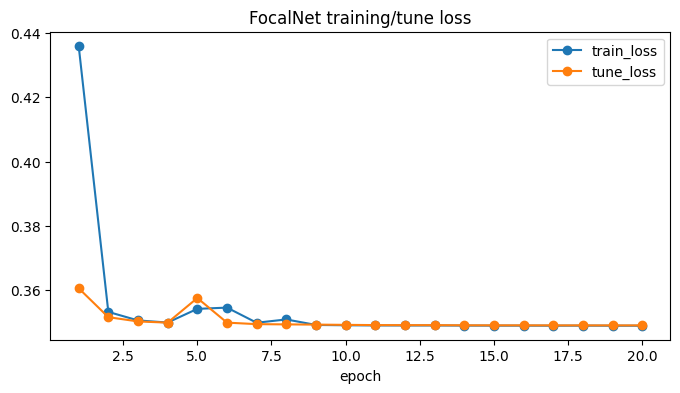

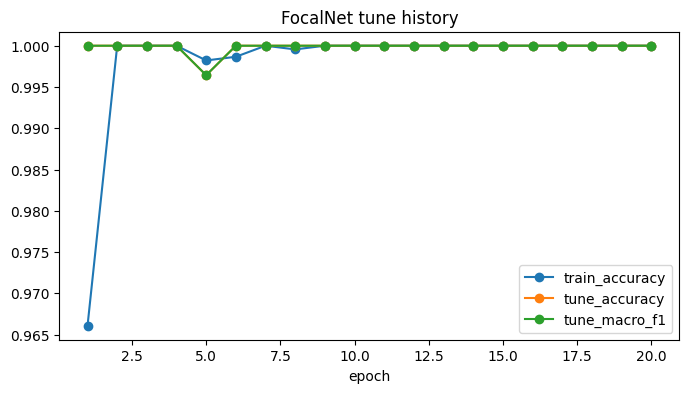

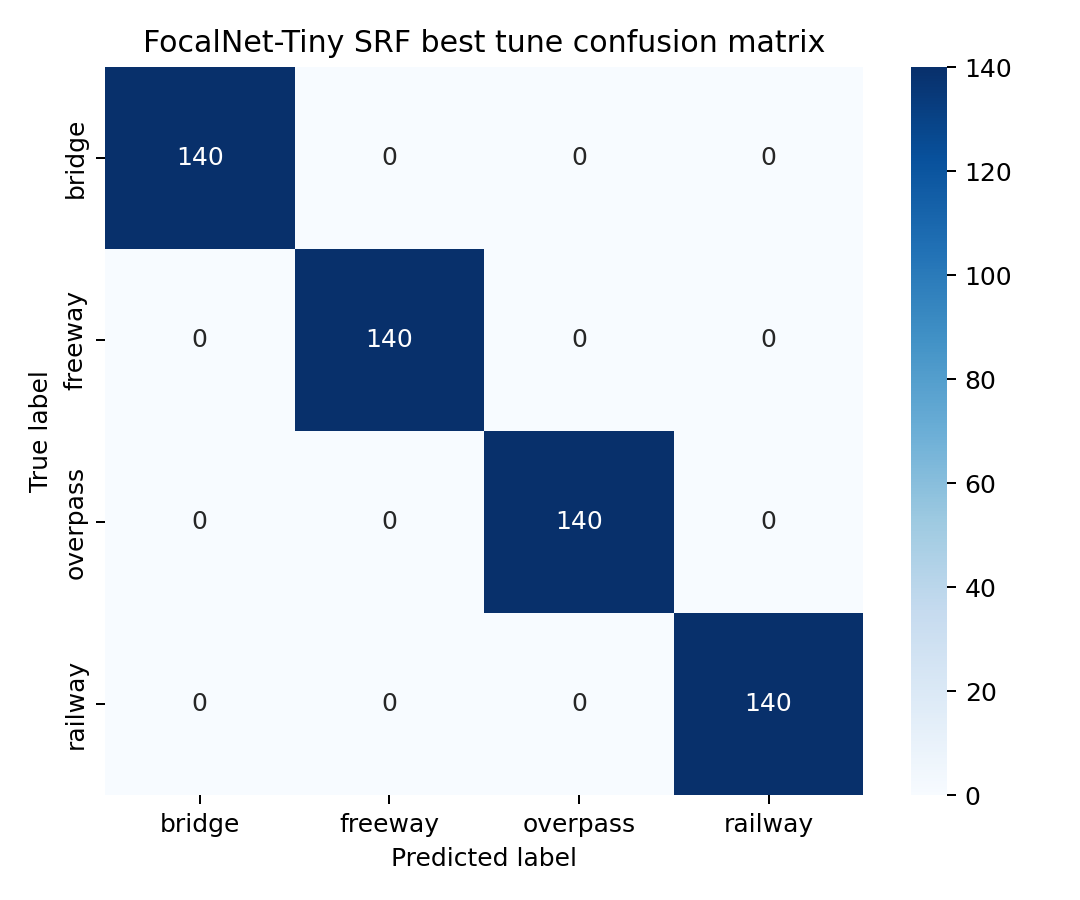

In [18]:
run_config_path = OUTPUT_DIR / 'run_config.json'
checkpoint_path = OUTPUT_DIR / 'best_model.pt'
history_path = OUTPUT_DIR / 'history.csv'

summary_row = {}
if run_config_path.exists():
    saved_run_config = json.loads(run_config_path.read_text(encoding='utf-8'))
    summary_row.update({
        'run_id': saved_run_config.get('run_id'),
        'run_started_at_utc': saved_run_config.get('created_at_utc'),
        'model_name': saved_run_config.get('model_name'),
        'epochs_requested': saved_run_config.get('epochs_to_run'),
    })
if checkpoint_path.exists():
    checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
    summary_row.update({
        'best_checkpoint_epoch': int(checkpoint['epoch']),
        'selection_reason': checkpoint.get('selection_reason'),
        'best_tune_macro_f1': float(checkpoint['metrics']['macro_f1']),
        'best_tune_loss': float(checkpoint.get('tune_loss', float('nan'))),
    })
if summary_row:
    display(pd.DataFrame([summary_row]))

if history_path.exists():
    history_df = pd.read_csv(history_path)
    display(history_df)
    ax = history_df.plot(x='epoch', y=['train_loss', 'tune_loss'], marker='o', figsize=(8, 4))
    ax.set_title('FocalNet training/tune loss')
    plt.show()
    ax = history_df.plot(x='epoch', y=['train_accuracy', 'tune_accuracy', 'tune_macro_f1'], marker='o', figsize=(8, 4))
    ax.set_title('FocalNet tune history')
    plt.show()

cm_path = OUTPUT_DIR / 'best_tune_confusion_matrix.png'
if cm_path.exists():
    display(Image.open(cm_path))

## 10. Final held-out evaluation

This is the result that matters most. After training has saved `best_model.pt`, the cell below reloads the selected checkpoint, evaluates once on `data/raw/val`, and shows the final metrics and confusion matrix directly in the notebook output.

If this cell has not run successfully in the saved notebook, then the notebook still does not prove held-out performance.

held-out validation:   0%|          | 0/25 [00:00<?, ?it/s]

,run_id,checkpoint_epoch,selection_reason,heldout_samples,errors,accuracy,macro_precision,macro_recall,macro_f1,loss
0,20260614T160323Z,19,macro-F1 tie broken by lower tune loss,400,1,0.9975,0.997525,0.9975,0.9975,0.085186


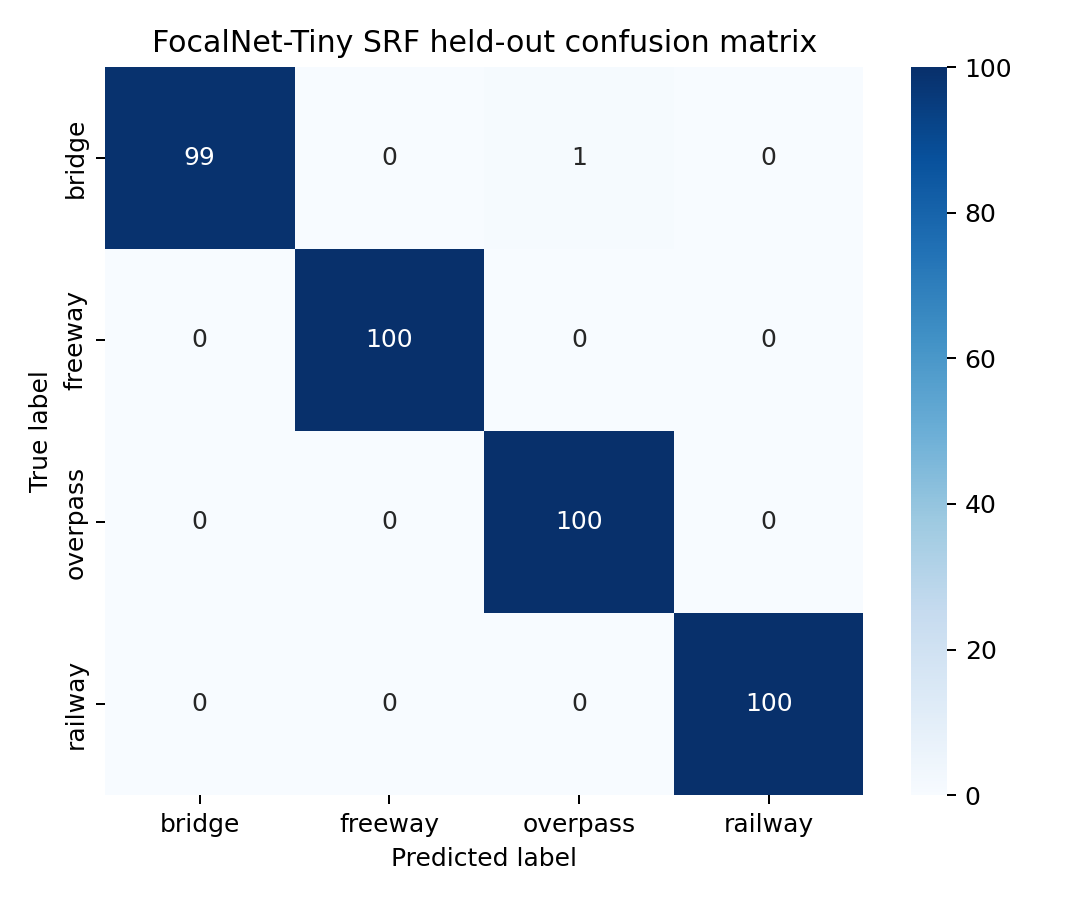

Final held-out evaluation complete.


In [19]:
checkpoint_path = OUTPUT_DIR / 'best_model.pt'
if not checkpoint_path.exists():
    raise FileNotFoundError(f'Missing checkpoint: {checkpoint_path}')
checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)

heldout_dataset = datasets.ImageFolder(
    HELDOUT_VAL_DIR,
    transform=build_eval_transform(IMAGE_SIZE, mean=mean, std=std, interpolation=interpolation),
)
if heldout_dataset.class_to_idx != checkpoint['class_to_idx']:
    raise ValueError((heldout_dataset.class_to_idx, checkpoint['class_to_idx']))
heldout_loader = DataLoader(heldout_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=device.type == 'cuda')

final_model = build_timm_classifier(
    num_classes=len(class_names),
    model_name=checkpoint['model_name'],
    pretrained=False,
    image_size=int(checkpoint['image_size']),
).to(device)
final_model.load_state_dict(checkpoint['model_state_dict'])
final_criterion = nn.CrossEntropyLoss(label_smoothing=0.0)
heldout_loss, heldout_acc, heldout_true, heldout_pred = evaluate_loop(final_model, heldout_loader, final_criterion, device, 'held-out validation', None)
heldout_metrics = classification_metrics(heldout_true, heldout_pred, class_names)
heldout_metrics['loss'] = float(heldout_loss)
heldout_metrics['source_data_dir'] = 'data/raw/val'
heldout_metrics['checkpoint_path'] = 'model/focalnet_tiny_srf_notebook/final/best_model.pt'
heldout_metrics['run_id'] = checkpoint.get('run_id', checkpoint.get('run_config', {}).get('run_id'))
heldout_metrics['checkpoint_epoch'] = int(checkpoint['epoch'])
heldout_metrics['selection_reason'] = checkpoint.get('selection_reason')
heldout_metrics['heldout_samples'] = len(heldout_dataset)
heldout_metrics['errors'] = int((np.asarray(heldout_true) != np.asarray(heldout_pred)).sum())

write_metrics_json(heldout_metrics, REPORT_DIR / 'metrics.json')
save_confusion_matrix_plot(heldout_metrics['confusion_matrix'], class_names, REPORT_DIR / 'confusion_matrix.png', title='FocalNet-Tiny SRF held-out confusion matrix')

display(pd.DataFrame([{
    'run_id': heldout_metrics['run_id'],
    'checkpoint_epoch': heldout_metrics['checkpoint_epoch'],
    'selection_reason': heldout_metrics['selection_reason'],
    'heldout_samples': heldout_metrics['heldout_samples'],
    'errors': heldout_metrics['errors'],
    'accuracy': heldout_metrics['accuracy'],
    'macro_precision': heldout_metrics['macro_precision'],
    'macro_recall': heldout_metrics['macro_recall'],
    'macro_f1': heldout_metrics['macro_f1'],
    'loss': heldout_metrics['loss'],
}]))
display(Image.open(REPORT_DIR / 'confusion_matrix.png'))
print('Final held-out evaluation complete.')

## 11. ONNX FP32 and INT8 QDQ deployment artifact check

FocalNet remains a notebook-first workflow. This final cell is a safety/readout check for the deployment artifacts generated from the notebook checkpoint lane. The quantized artifact is ONNX Runtime static INT8 QDQ/PTQ evaluated on the held-out `data/val 12` split.

Unlike Semantic-Guided CG-AF CNN, FocalNet is a classification-only fine-tuning baseline on the small target dataset, so calibrated post-training QDQ is used instead of adding QAT to the notebook fine-tuning loop.

In [20]:
FOCALNET_ONNX_DIR = PROJECT_ROOT / 'model' / 'focalnet_tiny_srf_onnx'
FOCALNET_ONNX_REPORT_DIR = PROJECT_ROOT / 'reports' / 'focalnet_tiny_srf_onnx_int8_qdq'
focalnet_onnx_summary_path = FOCALNET_ONNX_REPORT_DIR / 'comparison_metrics.csv'
focalnet_onnx_summary = pd.read_csv(focalnet_onnx_summary_path).round(4)
focalnet_onnx_artifacts = pd.DataFrame([
    {'artifact': 'ONNX FP32', 'path': 'model/focalnet_tiny_srf_onnx/focalnet_tiny_srf_fp32.onnx'},
    {'artifact': 'ONNX INT8 QDQ', 'path': 'model/focalnet_tiny_srf_onnx/focalnet_tiny_srf_int8_qdq.onnx'},
    {'artifact': 'ONNX/QDQ comparison metrics', 'path': 'reports/focalnet_tiny_srf_onnx_int8_qdq/comparison_metrics.csv'},
])
focalnet_onnx_artifacts['exists'] = focalnet_onnx_artifacts['path'].map(lambda p: (PROJECT_ROOT / p).exists())
if not focalnet_onnx_artifacts['exists'].all():
    raise FileNotFoundError(focalnet_onnx_artifacts.loc[~focalnet_onnx_artifacts['exists'], 'path'].to_list())
print('FocalNet ONNX/QDQ comparison metrics:')
print(focalnet_onnx_summary.to_string(index=False))
print('\nFocalNet deployment artifacts:')
print(focalnet_onnx_artifacts.to_string(index=False))

FocalNet ONNX/QDQ comparison metrics:
       variant  accuracy  macro_precision  macro_recall  macro_f1  samples
    torch_fp32     0.995           0.9951         0.995    0.995      400
    onnx_fp32     0.995           0.9951         0.995    0.995      400
onnx_int8_qdq     0.995           0.9951         0.995    0.995      400

FocalNet deployment artifacts:
                              artifact                                                                  path  exists
                           ONNX FP32                model/focalnet_tiny_srf_onnx/focalnet_tiny_srf_fp32.onnx    True
                       ONNX INT8 QDQ            model/focalnet_tiny_srf_onnx/focalnet_tiny_srf_int8_qdq.onnx    True
ONNX/QDQ comparison metrics reports/focalnet_tiny_srf_onnx_int8_qdq/comparison_metrics.csv    True
